In [2]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
from datetime import date, timedelta
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from matplotlib.colors import TwoSlopeNorm
from matplotlib import colors
#warning
import warnings
warnings.filterwarnings('ignore')

In [3]:
#dir = 'D:/yuanqi/new_pdm/seperatebaseflow/'
dir_topo = 'D:/yuanqi/new urania partition/camels_600.txt'
camels_info = pd.read_csv(dir_topo, delimiter=';')
camels_info = camels_info.sort_values(by='aridity').reset_index(drop=True)
gauge_id = camels_info['gauge_id'].values.astype(np.int64)

In [4]:
sdate = date(1987,1,1)
edate = date(2014,12,31)
ddate = pd.date_range(start=sdate, end=edate, freq='D')

In [5]:
datad = pd.read_csv('D:/yuanqi/new urania partition/camels_600.txt',delimiter=';')
domination = pd.read_csv("D:/yuanqi/new urania partition/seasonal_domi_regroup_rs.csv")

In [6]:

# Convert 'catchment id' in mean_annual_sum_cat_rirs to int64
#domination['catchment id'] = mean_annual_sum_cat_rirs['catchment id'].astype(int)

# Merge with datad
datad = datad.merge(domination, left_on='gauge_id', right_on='gauge_id')



##### Land cover info

In [7]:
## Vegetation cover
dir_vegetation = ('D:/yuanqi/new_pdm/camels_attributes_v2.0/camels_attributes_v2.0/')
camels_vege = pd.read_csv(dir_vegetation + "camels_vege.txt",delimiter=';')
camels_climx = pd.read_csv(dir_vegetation + "camels_clim.txt",delimiter=';')              
camels_topo = pd.read_csv(dir_vegetation + "camels_topo.txt",delimiter=';')
camels_topo = camels_topo.merge(camels_climx,left_on='gauge_id',right_on='gauge_id')
camels_vegex = camels_vege.merge(datad, 
                                 on='gauge_id').merge(camels_topo, on='gauge_id')


In [8]:
# xarray
import geopandas as gpd
import xarray 
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import proplot as pplt
mpl.rcParams['xtick.labelsize'] = 12
mpl.rcParams['ytick.labelsize'] = 12
CRS = "EPSG:5070"

In [9]:
### gdf                                                          
camels_vege_finaly_gdf = gpd.GeoDataFrame(camels_vegex, geometry=gpd.points_from_xy(
                             camels_vegex.gauge_lon, camels_vegex.gauge_lat))
camels_vege_finaly_gdf.crs = "EPSG:4326"
camels_vege_finaly_gdf = camels_vege_finaly_gdf.to_crs(CRS)
camels_vege_finaly_gdf['lond'] = np.array(camels_vege_finaly_gdf.geometry.x)
camels_vege_finaly_gdf['latd'] = np.array(camels_vege_finaly_gdf.geometry.y)

#xarray
camels_vege_finaly_gdfXarray = camels_vege_finaly_gdf.to_xarray()
camels_vege_finaly_gdfXarray = camels_vege_finaly_gdfXarray.set_coords(['lond', 'latd'])

In [10]:
conus_states = gpd.read_file('D:/tl_2017_us_state/tl_2017_us_state.shp')

four types map

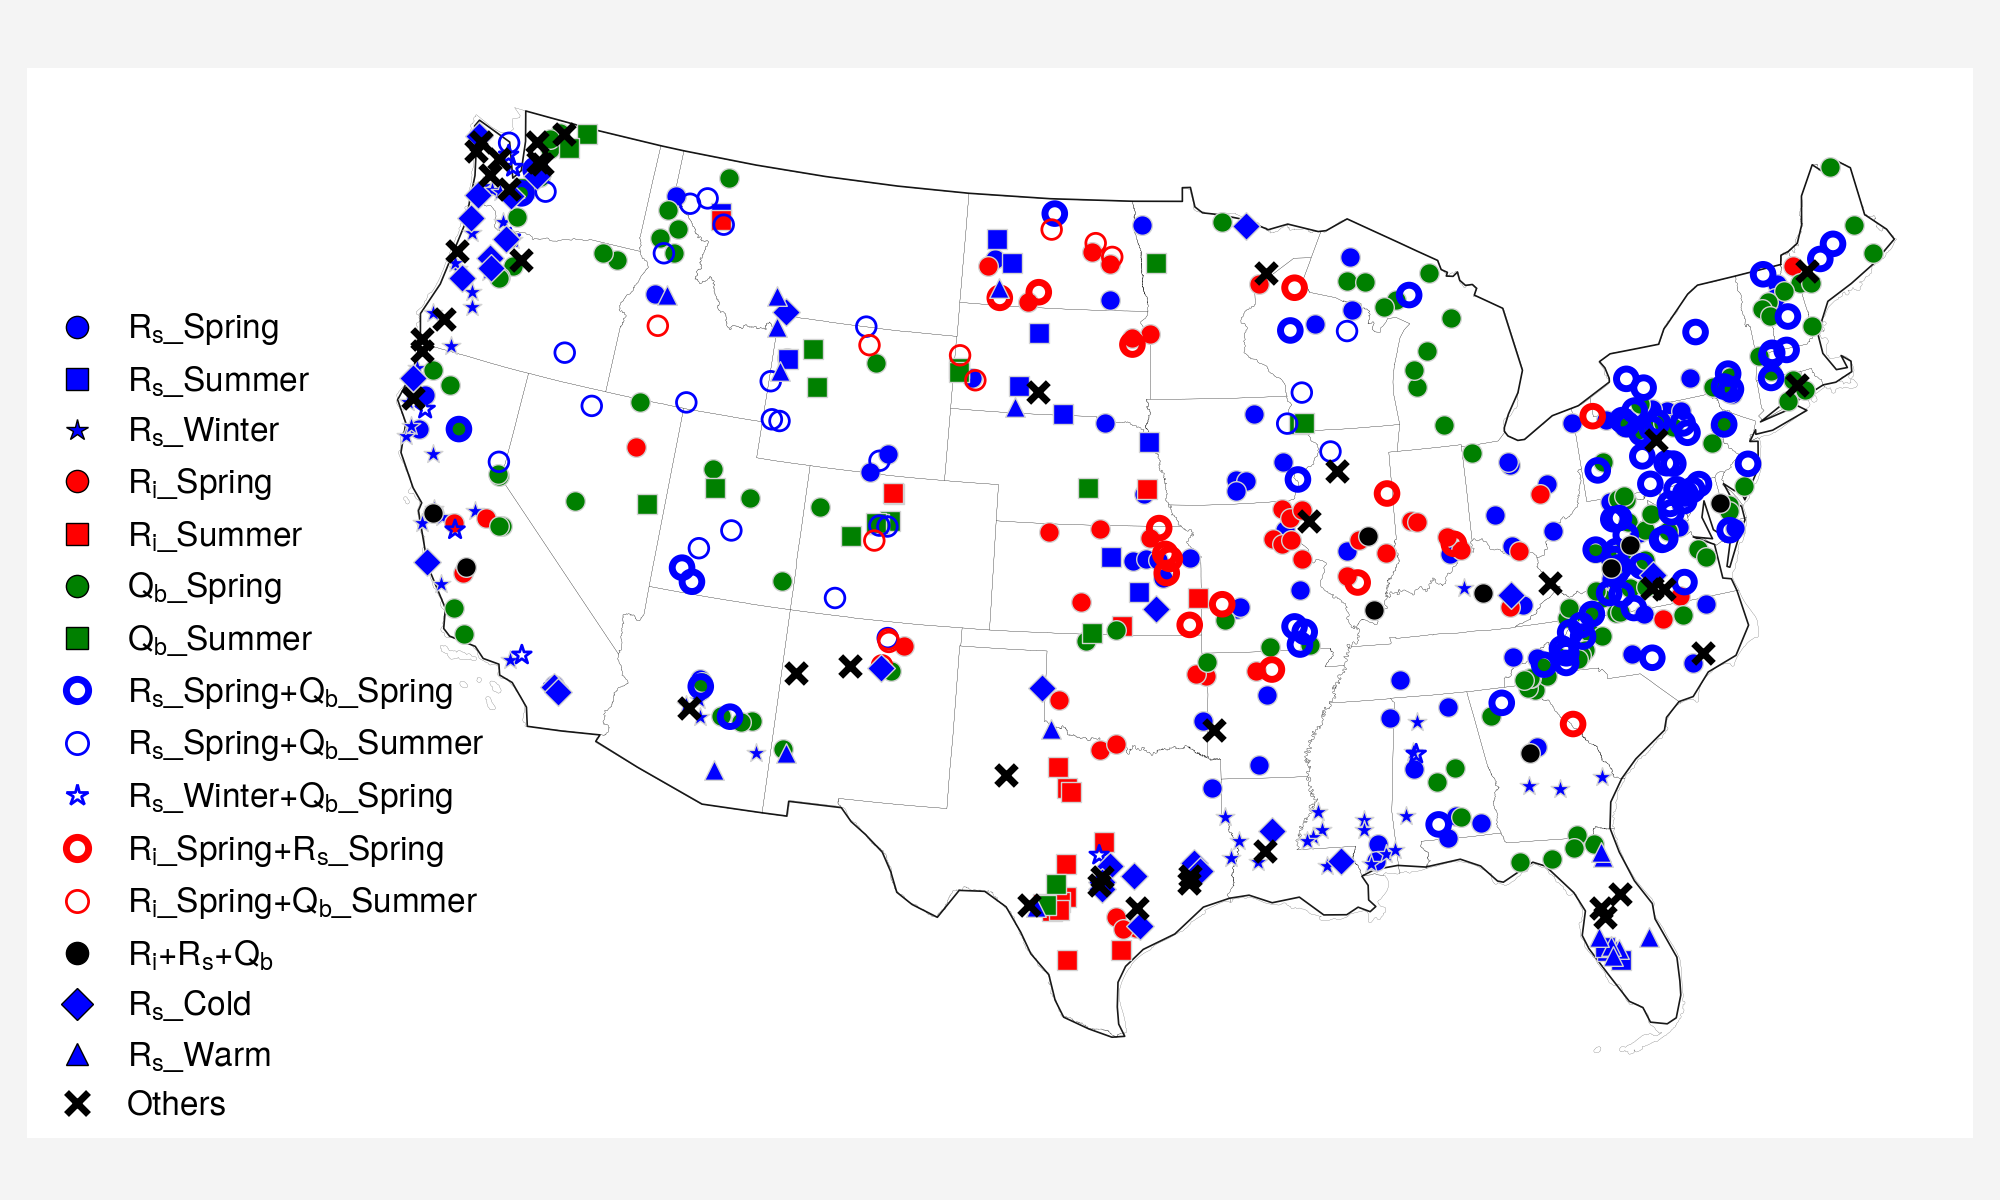

In [18]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.lines as mlines
import geopandas as gpd

# === 1️⃣ Define category styles ===
category_styles = {
    "rs_spring_domi": {"color": "blue", "marker": "o"},
    "rs_summer_domi": {"color": "blue", "marker": "s"},
    "rs_winter_domi": {"color": "blue", "marker": "*"},
    "ri_spring_domi": {"color": "red", "marker": "o"},
    "ri_summer_domi": {"color": "red", "marker": "s"},
    "qb_spring_domi": {"color": "green", "marker": "o"},
    "qb_summer_domi": {"color": "green", "marker": "s"},

    # hollow symbols — combinations
    "rs_spring_domi+qb_spring_domi": {
        "facecolor": "none",
        "edgecolor": "blue",
        "marker": "o",
        "linewidth": 2.5
    },
    "rs_spring_domi+qb_summer_domi": {
        "facecolor": "none",
        "edgecolor": "blue",
        "marker": "o",
        "linewidth": 1
    },
    "rs_winter_domi+qb_spring_domi": {
        "facecolor": "none",
        "edgecolor": "blue",
        "marker": "*",
        "linewidth": 1
    },
    "ri_spring_domi+rs_spring_domi": {
        "facecolor": "none",
        "edgecolor": "red",
        "marker": "o",
        "linewidth": 2.5
    },
    "ri_spring_domi+qb_summer_domi": {
        "facecolor": "none",
        "edgecolor": "red",
        "marker": "o",
        "linewidth": 1
    },
    "ri_rs_qb_domi": {"color": "black", "marker": "o"},
    "rs_cold": {"color": "blue", "marker": "D"},
    "rs_warm": {"color": "blue", "marker": "^"},
    "others": {"color": "black", "marker": "x", "linewidth": 2.5},
}

# === 2️⃣ Category label map (with subscripts) ===
label_map = {
    "rs_spring_domi": r"$R_s$_Spring",
    "rs_summer_domi": r"$R_s$_Summer",
    "rs_winter_domi": r"$R_s$_Winter",
    "ri_spring_domi": r"$R_i$_Spring",
    "ri_summer_domi": r"$R_i$_Summer",
    "qb_spring_domi": r"$Q_b$_Spring",
    "qb_summer_domi": r"$Q_b$_Summer",
    "rs_spring_domi+qb_spring_domi": r"$R_s$_Spring+$Q_b$_Spring",
    "rs_spring_domi+qb_summer_domi": r"$R_s$_Spring+$Q_b$_Summer",
    "rs_winter_domi+qb_spring_domi": r"$R_s$_Winter+$Q_b$_Spring",
    "ri_spring_domi+rs_spring_domi": r"$R_i$_Spring+$R_s$_Spring",
    "ri_spring_domi+qb_summer_domi": r"$R_i$_Spring+$Q_b$_Summer",
    "ri_rs_qb_domi": r"$R_i$+$R_s$+$Q_b$",
    "rs_cold": r"$R_s$_Cold",
    "rs_warm": r"$R_s$_Warm",
    "others": "Others",
}

# === 3️⃣ Convert your xarray to dataframe ===
df = camels_vege_finaly_gdfXarray.to_dataframe().reset_index()

# === 4️⃣ Base map settings ===
SAVE_KWDS = {"bbox_inches": "tight", "dpi": 450, "facecolor": "w"}
BASE_PLOT = {"facecolor": 'none', "edgecolor": 'k', "alpha": 0.9, "linewidth": 0.07}
BASE_PLOT1 = {"facecolor": 'none', "edgecolor": 'k', "alpha": 0.9}

# === 5️⃣ Load map data ===
world = gpd.read_file("D:/yuanqi/ne_110m_admin_0_countries/ne_110m_admin_0_countries.shp")
conus = world[world["ADMIN"] == "United States of America"]

fig, ax = plt.subplots(figsize=(10, 6))
conus_states.to_crs(CRS).plot(ax=ax, **BASE_PLOT)
conus.to_crs(CRS).plot(ax=ax, **BASE_PLOT1)

# === 6️⃣ Plot each category ===
for category, style in category_styles.items():
    df_cat = df[df['merged_group'] == category]
    ax.scatter(
        df_cat['lond'], df_cat['latd'],
        s=50,
        c=style.get('color', 'none'),
        edgecolors=style.get('edgecolor', 'lightgrey'),
        linewidth=style.get('linewidth', 0.5),
        marker=style['marker']
    )

# === 7️⃣ Custom legend with subscripts ===
legend_handles = []
for category, style in category_styles.items():
    legend_handles.append(mlines.Line2D(
        [], [], 
        marker=style['marker'], 
        color=style.get('color', 'none'), 
        markerfacecolor=style.get('color', 'none'),
        markeredgecolor=style.get('edgecolor', 'black'),
        markersize=8,
        markeredgewidth=style.get('linewidth', 0.5),
        linestyle='None',
        label=label_map.get(category, category)
    ))

ax.legend(handles=legend_handles, loc='lower left', frameon=False, prop={'size': 12})

# === 8️⃣ Clean plot style ===
ax.grid(False)
ax.set_xticks([]); ax.set_yticks([])
ax.xaxis.set_visible(False); ax.yaxis.set_visible(False)
ax.set_ylim([0, 3.3 * 1e6]); ax.set_xlim([-3.5 * 1e6, 2.5 * 1e6])
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.savefig('D:/yuanqi/new urania partition/domination_map_allgroups.png', **SAVE_KWDS)
plt.show()
